# **Welcome to SAC's NFL Pick 'Em Workshop! 🏈**

## In this NFL Pick 'Em Workshop with Machine Learning we will cover the following:
1) Fetching and cleaning NFL Regular Season Game Data
2) Developing visualizations to uncover historical NFL Data Trends
3) Building models to predict weekly NFL Matchups
4) Evaluating and fine-tuning model performance

### **1. Importing AND Installing Modules**


---
In this section, we will be installing the required packages to work with NFL data and importing modules which are toolkits in Python to help us with data cleaning, visualization, and model building.


In [ ]:
# RUN THIS CELL FIRST! We will be using this package!
!pip install nflreadpy

# TODO: Import pandas, nflreadpy, and visualization libraries
import nflreadpy as nfl # allows us to fetch NFL data easily
import pandas as pd # helps us clean and analyze data frames
import numpy as np # library in python for arrays
import matplotlib.pyplot as plt # library for plotting
import seaborn as sns # library for advanced plotting

# TODO: Import our modeling and evaluation tools from sklearn and xgboost
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import ParameterGrid

### **2. Fetching Data and Initial Cleaning**

---



For this workshop, we will use the `nflreadpy` package to easily access NFL data (schedules, player stats, team stats, and much more!).

To learn more, check out the documentation: **https://github.com/nflverse/nflreadpy**

In [ ]:
# Loads in the teams stats game-by-game for every team from 1999 to 2025
nfl_team_stats = nfl.load_team_stats(seasons = True)

# Converts the nfl team stats data into a pandas data frame
nfl_team_stats = nfl_team_stats.to_pandas()

# Allows us to view nfl_team_stats
nfl_team_stats

,season,week,team,season_type,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,...,pat_made,pat_att,pat_missed,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance
0,1999,1,ARI,REG,PHI,25,48,274,1,3,...,1,1,0,0,1.0,1,1,0,0,31
1,1999,1,ATL,REG,MIN,18,31,290,1,0,...,2,2,0,0,1.0,0,0,0,0,0
2,1999,1,BUF,REG,IND,22,42,300,1,2,...,0,0,0,0,NaN,0,0,0,0,0
3,1999,1,CAR,REG,NO,16,32,207,1,1,...,1,1,0,0,1.0,0,0,0,0,0
4,1999,1,CHI,REG,KC,31,47,322,2,0,...,2,2,0,0,1.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14052,2025,3,SEA,REG,NO,16,21,233,2,0,...,5,5,0,0,1.0,0,0,0,0,0
14053,2025,3,SF,REG,ARI,27,41,284,1,1,...,1,1,0,0,1.0,1,1,0,0,35
14054,2025,3,TB,REG,NYJ,19,29,233,1,0,...,2,2,0,0,1.0,1,1,0,0,36
14055,2025,3,TEN,REG,IND,23,38,219,1,1,...,2,2,0,0,1.0,0,0,0,0,0


In [ ]:
# Loads in the game schedules and results game by game from 1999 to 2025
nfl_sched = nfl.load_schedules()

# Converts the nfl schedule data into a pandas data frame
nfl_sched = nfl_sched.to_pandas()

# Allows us to view nfl_sched
nfl_sched

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,None,MIN,17.0,ATL,...,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,None,KC,17.0,CHI,...,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,None,PIT,43.0,CLE,...,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,None,OAK,24.0,GB,...,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,None,BUF,14.0,IND,...,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7258,2025_18_DAL_NYG,2025,REG,18,2026-01-04,Sunday,13:00,DAL,NaN,NYG,...,NaN,None,None,None,None,Brian Schottenheimer,Brian Daboll,None,NYC01,MetLife Stadium
7259,2025_18_WAS_PHI,2025,REG,18,2026-01-04,Sunday,13:00,WAS,NaN,PHI,...,NaN,None,None,None,None,Dan Quinn,Nick Sirianni,None,PHI00,Lincoln Financial Field
7260,2025_18_BAL_PIT,2025,REG,18,2026-01-04,Sunday,13:00,BAL,NaN,PIT,...,NaN,None,None,None,None,John Harbaugh,Mike Tomlin,None,PIT00,Acrisure Stadium
7261,2025_18_SEA_SF,2025,REG,18,2026-01-04,Sunday,13:00,SEA,NaN,SF,...,NaN,None,None,None,None,Mike Macdonald,Kyle Shanahan,None,SFO01,Levi's Stadium


In [ ]:
# Let's first focus on the nfl_team_stats data

# Check for null values in the data
null_counts = nfl_team_stats.isna().sum()
null_counts = null_counts[null_counts > 0]

# First, drop the entry with team and opponent_team being NULL
nfl_team_stats = nfl_team_stats[nfl_team_stats["team"].isna() == False]

# Next, let's fill all of the missing numerical stats with zeros
# TODO: Fill the NA values in the dataframe with 0
nfl_team_stats = nfl_team_stats.fillna(0)

# Additionally, the data is inconsistent with JAX/JAC. We will remove 'JAC'.
nfl_team_stats = nfl_team_stats[(nfl_team_stats['team'] != 'JAC') |
                                (nfl_team_stats['opponent_team'] != 'JAC')]

### **3. Data Visualization and Analysis**

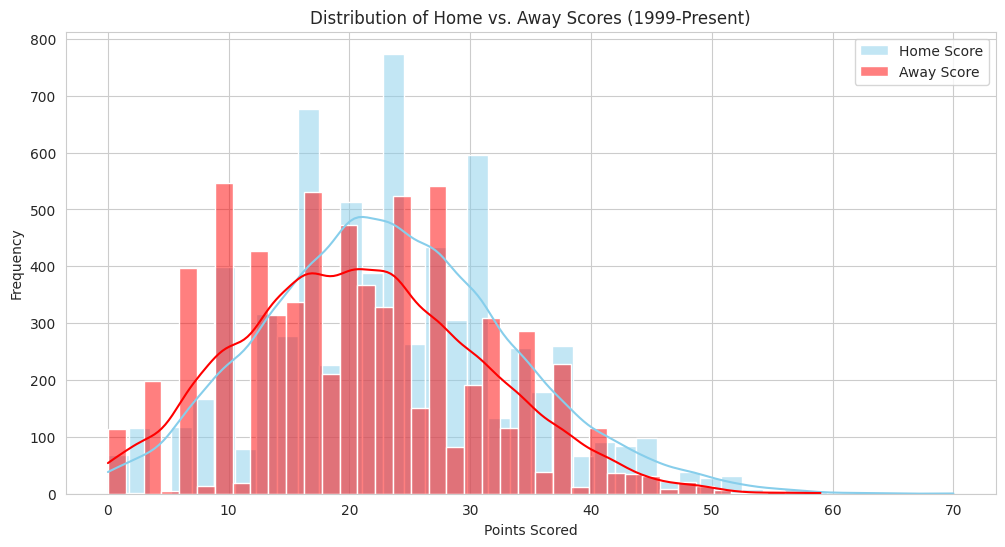

In [ ]:
# Set a style for the plots
sns.set_style("whitegrid")

# We will use the 'nfl_sched' dataframe for these plots, as it contains game results.
# Let's filter out games that haven't been played yet.
sched_played = nfl_sched.dropna(subset=['result'])

# TODO: Create a histogram to show the distribution of Home vs. Away Scores
plt.figure(figsize=(12, 6))
sns.histplot(sched_played['home_score'], color='skyblue', kde=True, label='Home Score', bins=40)
sns.histplot(sched_played['away_score'], color='red', kde=True, label='Away Score', bins=40)
plt.title('Distribution of Home vs. Away Scores (1999-Present)')
plt.xlabel('Points Scored')
plt.ylabel('Frequency')
plt.legend()
plt.show()

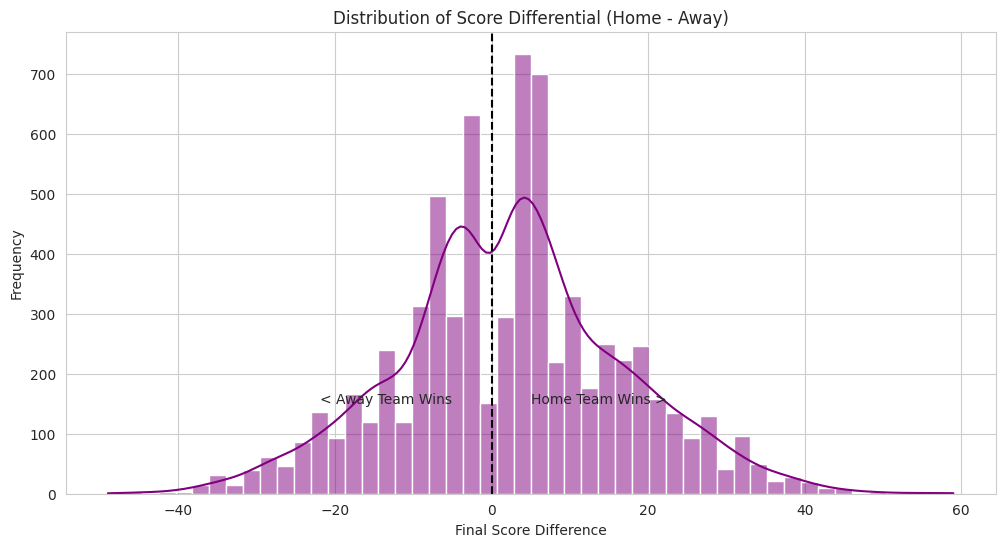

In [ ]:
# TODO: Create a histogram of the score differential (the 'result' column)
plt.figure(figsize=(12, 6))
sns.histplot(sched_played['result'], color='purple', kde=True, bins=50)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Distribution of Score Differential (Home - Away)')
plt.xlabel('Final Score Difference')
plt.ylabel('Frequency')
plt.text(5, 150, 'Home Team Wins >', ha='left')
plt.text(-5, 150, '< Away Team Wins', ha='right')
plt.show()

### **4. Advanced Cleaning & Feature Engineering**

In this section, we will prepare the data for our model.
The goal is to create a single row for each game, containing the rolling historical stats for both teams.

In [ ]:
# We only select variables that are needed from nfl_sched
nfl_sched = nfl_sched[['game_id', 'season', 'game_type', 'week', 'gameday',
                       'away_team', 'away_score', 'home_team', 'home_score',
                       'result', 'total']]

# TODO: Fix team name changes for relocation/rebrand (e.g., OAK -> LV)
team_map = {"OAK": "LV", "SD": "LAC", "STL": "LA"}
nfl_sched['home_team'] = nfl_sched['home_team'].replace(team_map)
nfl_sched['away_team'] = nfl_sched['away_team'].replace(team_map)

# Re-create a consistent game_id to merge on, since we changed team names
# TODO: Create the 'game_id' column using season, week, away_team, and home_team
nfl_sched["game_id"] = (
    nfl_sched["season"].astype(str) + "_" +
    nfl_sched["week"].astype(str).str.zfill(2) + "_" +
    nfl_sched["away_team"] + "_" +
    nfl_sched["home_team"]
)

In [ ]:
nfl_sched

,game_id,season,game_type,week,gameday,away_team,away_score,home_team,home_score,result,total
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,MIN,17.0,ATL,14.0,-3.0,31.0
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,KC,17.0,CHI,20.0,3.0,37.0
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,PIT,43.0,CLE,0.0,-43.0,43.0
3,1999_01_LV_GB,1999,REG,1,1999-09-12,LV,24.0,GB,28.0,4.0,52.0
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,BUF,14.0,IND,31.0,17.0,45.0
...,...,...,...,...,...,...,...,...,...,...,...
7258,2025_18_DAL_NYG,2025,REG,18,2026-01-04,DAL,NaN,NYG,NaN,NaN,NaN
7259,2025_18_WAS_PHI,2025,REG,18,2026-01-04,WAS,NaN,PHI,NaN,NaN,NaN
7260,2025_18_BAL_PIT,2025,REG,18,2026-01-04,BAL,NaN,PIT,NaN,NaN,NaN
7261,2025_18_SEA_SF,2025,REG,18,2026-01-04,SEA,NaN,SF,NaN,NaN,NaN


In [ ]:
# One problem! The nfl_team_stats data does not contain the result of the game!
# We need to figure out a way to combine the nfl_team_stats and nfl_sched data

# To merge, we need to create matching game_id formats in the stats table
# Because we don't know who was home/away in this table, we create both possibilities
nfl_team_stats['game_id_awayhome'] = (
    nfl_team_stats['season'].astype(str) + '_' +
    nfl_team_stats['week'].astype(str).str.zfill(2) + '_' +
    nfl_team_stats['team'].astype(str) + '_' +
    nfl_team_stats['opponent_team'].astype(str)
)

# TO DO: Flip opponent_team and team for game_id_homeaway
nfl_team_stats['game_id_homeaway'] = (
    nfl_team_stats['season'].astype(str) + '_' +
    nfl_team_stats['week'].astype(str).str.zfill(2) + '_' +
    nfl_team_stats['opponent_team'].astype(str) + '_' +
    nfl_team_stats['team'].astype(str)
)

In [ ]:
# TODO: Merge the dataframes twice to catch all matchups
# Merge the nfl_team_stats and nfl_sched data with game_id_awayhome
merged1 = nfl_team_stats.merge(
    nfl_sched[['game_id', 'away_team', 'home_team', 'away_score',
               'home_score', 'result']],
    left_on = "game_id_awayhome",
    right_on = "game_id",
    how = "inner"
)

# Merge the nfl_team_stats and nfl_sched_data with game_id_homeaway
merged2 = nfl_team_stats.merge(
    nfl_sched[['game_id', 'away_team', 'home_team', 'away_score',
               'home_score', 'result']],
    left_on = "game_id_homeaway",
    right_on = "game_id",
    how = "inner"
)

# Combine both merged dataframes
nfl_sched_team_stats = pd.concat([merged1, merged2], ignore_index=True)

In [ ]:
# Feature Engineering: Rolling Averages
nfl_long = nfl_sched_team_stats.copy()

# Only select numeric columns from the nfl_long data
numeric_cols = [col for col in nfl_long.columns if col not in ['season', 'week', 'season_type',
                                                               'team', 'opponent_team', 'game_id',
                                                               'game_id_awayhome', 'game_id_homeaway',
                                                               'home_team', 'away_team',
                                                               'fg_made_list', 'fg_missed_list', 'fg_blocked_list']]

# TODO: Calculate the rolling average for each numeric column.
# HINT: Group by team and season, then use transform with shift(), expanding(), and mean().
for col in numeric_cols:
  if col not in ['season', 'week']:
    nfl_long[col] = (
        nfl_long.groupby(['team', 'season'])[col]
        .transform(lambda x: x.shift().expanding().mean())
    )

# TO DO: For Week 1 games, the rolling average is NaN. We'll fill it with the previous season's average.
prev_season_avg = nfl_long.groupby(['team', 'season'])[numeric_cols].mean().groupby(level=0).shift(1)

for col in numeric_cols:
    if col not in ['season', 'week']:
        nfl_long[col] = nfl_long.apply(
            lambda row: prev_season_avg.loc[(row['team'], row['season']), col] if pd.isna(row[col]) else row[col],
            axis=1
        )

# Fill any remaining NaNs with zero
nfl_long.fillna(0, inplace=True)

In [ ]:
# TODO: Now, we would like to collapse the nfl_sched_team_stats data to have one entry
#   for every game played. This reduces repetition in the dataset and will be
#   useful for model building.
team_a = nfl_long[nfl_long['team'] == nfl_long['away_team']].copy()
team_b = nfl_long[nfl_long['team'] == nfl_long['home_team']].copy()

# Select the required columns for merging from a and b
cols_to_drop_a = ['opponent_team', 'game_id_awayhome', 'game_id_homeaway', 'home_score',
                  'result']
cols_to_drop_b = ['opponent_team', 'game_id_awayhome', 'game_id_homeaway', 'away_score',
                  'season', 'week', 'season_type', 'result', 'away_team', 'home_team']

team_a.drop(columns=cols_to_drop_a, inplace=True)
team_b.drop(columns=cols_to_drop_b, inplace=True)

# TO DO: Rename the columns with _team_a and _team_b suffix
team_a = team_a.rename(columns={col: f"{col}_team_a" for col in team_a.columns if col not in ['game_id', 'season', 'week', 'season_type',
                                                                                              'away_team', 'home_team', 'result']})
# Rename team_team_a and away_score_team_a columns for clarity
team_a = team_a.rename(columns={'team_team_a': 'team_a', 'away_score_team_a': 'team_a_score'})

# TO DO: Rename columns for team_b by adding '_team_b' to numerical columns in the team b data
team_b = team_b.rename(columns={col: f"{col}_team_b" for col in team_b.columns if col not in ['game_id', 'away_team', 'home_team', 'result']})

# Rename team_team_b and away_score_team_b columns for clarity
team_b = team_b.rename(columns={'team_team_b': 'team_b', 'home_score_team_b': 'team_b_score'})

In [ ]:
# Merge the cleaned team_a and team_b data frames to one data frame
nfl_merged_final = team_a.merge(team_b, on='game_id', how='inner')

In [ ]:
# Remove the list columns before calculating differential statistics
list_cols = ['fg_made_list', 'fg_missed_list', 'fg_blocked_list']
team_a_cols = [
    col for col in nfl_merged_final.columns
    if col.endswith('_team_a') and col.replace('_team_a', '') not in list_cols
]
print(team_a_cols)

# TO DO: Calculate the differential statistics
for col in team_a_cols:
  base = col.replace('_team_a', '')
  col_a = f"{base}_team_a"
  col_b = f"{base}_team_b"
  nfl_merged_final[f"{base}_diff"] = nfl_merged_final[col_a] - nfl_merged_final[col_b]

# Drops the original _team_a and _team_b columns now that the differential
#   columns capture the data between team_a and team_b
nfl_model_final = nfl_merged_final.drop(
    columns=[col for col in nfl_merged_final.columns if col.endswith('_team_a') or col.endswith('_team_b')]
)

# TO DO: Create our target variable: 'team_a_win' (1 if away team won, 0 if home team won)
nfl_model_final['team_a_win'] = (nfl_model_final['team_a_score'] > nfl_model_final['team_b_score']).astype(int)

# Only consider regular season games
nfl_model_final = nfl_model_final[nfl_model_final['season_type'] == 'REG']

['completions_team_a', 'attempts_team_a', 'passing_yards_team_a', 'passing_tds_team_a', 'passing_interceptions_team_a', 'sacks_suffered_team_a', 'sack_yards_lost_team_a', 'sack_fumbles_team_a', 'sack_fumbles_lost_team_a', 'passing_air_yards_team_a', 'passing_yards_after_catch_team_a', 'passing_first_downs_team_a', 'passing_epa_team_a', 'passing_cpoe_team_a', 'passing_2pt_conversions_team_a', 'carries_team_a', 'rushing_yards_team_a', 'rushing_tds_team_a', 'rushing_fumbles_team_a', 'rushing_fumbles_lost_team_a', 'rushing_first_downs_team_a', 'rushing_epa_team_a', 'rushing_2pt_conversions_team_a', 'receptions_team_a', 'targets_team_a', 'receiving_yards_team_a', 'receiving_tds_team_a', 'receiving_fumbles_team_a', 'receiving_fumbles_lost_team_a', 'receiving_air_yards_team_a', 'receiving_yards_after_catch_team_a', 'receiving_first_downs_team_a', 'receiving_epa_team_a', 'receiving_2pt_conversions_team_a', 'special_teams_tds_team_a', 'def_tackles_solo_team_a', 'def_tackles_with_assist_team_a',

### **5. Model Building & Evaluation**
---
In this section, we will be using predictive models such as xgboost to build the model, fine-tune, and predict this upcoming week's matchups.

In [ ]:
# Filter for regular season games only and split data into training and testing sets
nfl_test_data = nfl_model_final[(nfl_model_final['season'] >= 2020)]
nfl_train_data = nfl_model_final[(nfl_model_final['season'] <= 2019)]

#TODO: Create the training and testing dataframes by dropping the columns listed above
features_to_drop = ['game_id', 'season', 'week', 'team_a', 'team_b', 'away_team', 'home_team',
                                             'season_type', 'team_a_win', 'team_a_score', 'team_b_score']

nfl_train_x = nfl_train_data.drop(columns = features_to_drop)

nfl_train_y = nfl_train_data['team_a_win']

nfl_test_x = nfl_test_data.drop(columns = features_to_drop)

nfl_test_y = nfl_test_data['team_a_win']

# Initialize SMOTE for class balance
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
nfl_train_x_smote, nfl_train_y_smote = smote.fit_resample(nfl_train_x, nfl_train_y)

print("Shape of training data after SMOTE:", nfl_train_x_smote.shape)
print("Class distribution after SMOTE:", nfl_train_y_smote.value_counts())

# Define a smaller parameter grid for quick tuning
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'random_state': [42]
}

# Track thea accuracy, parameters, and results of the different models
best_accuracy = 0
best_params = {}
results = []

'''
# Perform grid search manually using the defined train/test split
for params in ParameterGrid(param_grid):
    xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', **params)
    xgb_model.fit(nfl_train_x_smote, nfl_train_y_smote)
    preds = xgb_model.predict(nfl_test_x)
    accuracy = accuracy_score(nfl_test_y, preds)

    results.append({'params': params, 'accuracy': accuracy})

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_params = params

    print(f"Params: {params}, Accuracy: {accuracy:.3f}")

print("\nBest parameters found:", best_params)
print(f"Best accuracy: {best_accuracy:.3f}")
'''

# This dictionary contains the best parameters found from hyperparameter tuning
best_params = {
    'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3,
    'n_estimators': 500, 'random_state': 42, 'subsample': 1.0
}

# TODO: Initialize the XGBClassifier, using the 'best_params' dictionary
final_xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', **best_params)

# TODO: Fit the model on the SMOTE-resampled training data
final_xgb_model.fit(nfl_train_x_smote, nfl_train_y_smote)

# Make predictions on the test data
final_preds = final_xgb_model.predict(nfl_test_x)

# TO DO: Calculate the accuracy score
print("\nFinal Model Evaluation:")
print("Test Accuracy:", accuracy_score(nfl_test_y, final_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(nfl_test_y, final_preds))

print("\nClassification Report:")
print(classification_report(nfl_test_y, final_preds))

Shape of training data after SMOTE: (6740, 94)
Class distribution after SMOTE: team_a_win
0    3370
1    3370
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:28:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Final Model Evaluation:
Test Accuracy: 0.790079079798706

Confusion Matrix:
[[695 140]
 [152 404]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       835
           1       0.74      0.73      0.73       556

    accuracy                           0.79      1391
   macro avg       0.78      0.78      0.78      1391
weighted avg       0.79      0.79      0.79      1391



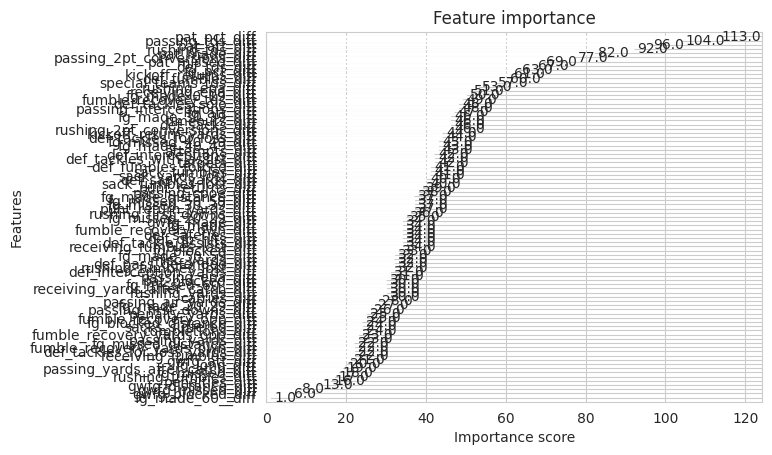

In [ ]:
# Shows the feature importance of the model when predicting the matchup
xgb.plot_importance(final_xgb_model, max_num_features=100, importance_type='weight')
plt.show()

In [ ]:
print("--- Preparing to Make Predictions for Week 3 of the 2025 Season ---")

wk3_schedule = nfl_sched[(nfl_sched['season'] == 2025) & (nfl_sched['week'] == 3)].copy()
wk3_schedule = wk3_schedule[['game_id', 'away_team', 'home_team']]

print(f"\nFound {len(wk3_schedule)} matchups for Week 3.")


--- Preparing to Make Predictions for Week 3 of the 2025 Season ---

Found 16 matchups for Week 3.


In [ ]:
# The 'nfl_long' dataframe contains the rolling averages for every team after every game.
latest_stats = nfl_long[(nfl_long['season'] == 2025) & (nfl_long['week'] == 2)].set_index('team')

# Merge with stats for the away team ('team_a')
wk3_merged = wk3_schedule.merge(
    latest_stats.add_suffix('_team_a'),
    left_on='away_team',
    right_index=True,
    how='left'
)

# Merge the result with stats for the home team ('team_b')
wk3_merged = wk3_merged.merge(
    latest_stats.add_suffix('_team_b'),
    left_on='home_team',
    right_index=True,
    how='left'
)

print("Calculating differential features for Week 3 matchups...")
team_a_cols_pred = [col for col in wk3_merged.columns if col.endswith('_team_a')]
wk3_model_input = wk3_merged.copy()

for col_a in team_a_cols_pred:
    if pd.api.types.is_numeric_dtype(wk3_model_input[col_a]):
        base = col_a.replace('_team_a', '')
        col_b = f"{base}_team_b"
        if col_b in wk3_model_input.columns and pd.api.types.is_numeric_dtype(wk3_model_input[col_b]):
            wk3_model_input[f"{base}_diff"] = wk3_model_input[col_a] - wk3_model_input[col_b]

wk3_model_input = wk3_model_input[nfl_train_x.columns]

# Handle any potential NaNs that might arise if a team had a bye week etc.
wk3_model_input.fillna(0, inplace=True)

Calculating differential features for Week 3 matchups...


/tmp/ipython-input-211779283.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wk3_model_input[f"{base}_diff"] = wk3_model_input[col_a] - wk3_model_input[col_b]
/tmp/ipython-input-211779283.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wk3_model_input[f"{base}_diff"] = wk3_model_input[col_a] - wk3_model_input[col_b]


In [ ]:
print("Making predictions...")
wk3_preds = final_xgb_model.predict(wk3_model_input)
wk3_pred_probs = final_xgb_model.predict_proba(wk3_model_input)

results_df = wk3_schedule.copy()
results_df['Away_Win_Prob'] = wk3_pred_probs[:, 1] # Probability of team_a (away team) winning
results_df['Home_Win_Prob'] = wk3_pred_probs[:, 0] # Probability of team_b (home team) winning
results_df['Predicted_Winner'] = np.where(results_df['Away_Win_Prob'] > 0.5, results_df['away_team'], results_df['home_team'])
results_df['Win_Probability'] = np.where(results_df['Away_Win_Prob'] > 0.5, results_df['Away_Win_Prob'], results_df['Home_Win_Prob'])

# Sort by the most confident picks
results_df = results_df.sort_values(by='Win_Probability', ascending=False)

print("\n\n--- NFL Pick 'Em Predictions: 2025 Season - Week 3 ---")
print(results_df[['away_team', 'home_team', 'Predicted_Winner', 'Win_Probability']].to_string(index=False))

Making predictions...


--- NFL Pick 'Em Predictions: 2025 Season - Week 3 ---
away_team home_team Predicted_Winner  Win_Probability
      PIT        NE              PIT         0.999994
       GB       CLE               GB         0.998587
       KC       NYG               KC         0.997043
      HOU       JAX              JAX         0.995544
      DET       BAL              BAL         0.994160
      DAL       CHI              DAL         0.992259
      MIA       BUF              BUF         0.986870
      CIN       MIN              MIN         0.965311
       NO       SEA              SEA         0.930384
       LV       WAS              WAS         0.799043
      ARI        SF               SF         0.637404
       LA       PHI              PHI         0.630610
      DEN       LAC              LAC         0.622891
      NYJ        TB              NYJ         0.593115
      IND       TEN              TEN         0.580503
      ATL       CAR              ATL         0.507481
